# 01 — Build Optic Lobe mcHH Model from Packed Simplified Morphologies

当前 notebook 统一作为 **optic lobe mcHH** 的主入口。

目标：

- 读取按 neuron type 打包的 `.bin` 形态文件
- 显示加载进度（多少 neurons）和内存占用
- 接到现有 `FAFBMCNetwork` 构建流程
- 暂时仍使用 shared morphology 做仿真，但同时把每个 neuron 的简化形态元数据挂到 network 上，方便下一步升级为真正 per-neuron mcHH


In [21]:
import sys, os, time, logging
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

from neuro_framework.models import (
    FAFBMCNetwork,
    PackedMorphologyLoader,
    estimate_package_memory,
)

print(f'PyTorch {torch.__version__}')

PyTorch 2.2.0


## 1. Paths

In [22]:
DATA_DIR = '../../mcHH/data/optic_lobe_right'
MORPH_PKG_DIR = '../../mcHH/data/optic_lobe_type_packages_v1'
ION_RULES = '../data/fafb_ion_channel_rules.csv'
SYN_RULES = '../data/fafb_synapse_rules.csv'

# Optional: neurotransmitter-level defaults (fallback when a type rule is missing)
NT_ION_RULES = None

# Optional: root_id-specific overrides, highest priority
ROOT_ION_OVERRIDES = None

DT = 0.1
NCOMP = 2
MIN_SYN_COUNT = 3

# Full per-neuron morphology build is safe but not instant: about 5-6 min on this machine.
MORPH_PROGRESS_EVERY = 5000

# Sanity check settings. Keep this short first; increase FLASH_I_AMP after stability is confirmed.
SANITY_T_PRE = 40.0
SANITY_T_ON = 10.0
SANITY_T_OFF = 30.0
SANITY_STABILITY_SECONDS = 180.0
SANITY_I_AMP = 30.0
# SANITY_I_AMP = 60.0
STRONG_SANITY_I_AMP = 60.0
R16_ELEAK_SHIFT_MV = -10.0  # make R1-6 resting potential more negative before stimulus
R16_VTH_SHIFT_MV = 8.0  # reduce tonic-on R1-6 output by raising its synaptic threshold
R16_SYNAPSE_GAIN = 1.0  # try 1.5-2.0 if R1-6 output remains too weak after equilibration
SANITY_PROGRESS_EVERY = 50

# Visualization settings. Never plot every neuron in the optic lobe directly.
SUMMARY_TYPES = ['R1-6', 'L1', 'L3', 'L5', 'Mi1', 'Mi9', 'Tm3', 'T4a', 'T5a']
MAX_SINGLE_NEURON_TRACES_PER_TYPE = 3
MORPH_SAMPLE_LIMIT = 300

print('DATA_DIR            =', DATA_DIR)
print('MORPH_PKG_DIR       =', MORPH_PKG_DIR)
print('ION_RULES           =', ION_RULES)
print('SYN_RULES           =', SYN_RULES)
print('NT_ION_RULES        =', NT_ION_RULES)
print('ROOT_ION_OVERRIDES  =', ROOT_ION_OVERRIDES)
print('DT, NCOMP           =', DT, NCOMP)
print('MIN_SYN_COUNT       =', MIN_SYN_COUNT)
print('R16_ELEAK_SHIFT_MV  =', R16_ELEAK_SHIFT_MV)
print('R16_VTH_SHIFT_MV    =', R16_VTH_SHIFT_MV)


DATA_DIR            = ../../mcHH/data/optic_lobe_right
MORPH_PKG_DIR       = ../../mcHH/data/optic_lobe_type_packages_v1
ION_RULES           = ../data/fafb_ion_channel_rules.csv
SYN_RULES           = ../data/fafb_synapse_rules.csv
NT_ION_RULES        = None
ROOT_ION_OVERRIDES  = None
DT, NCOMP           = 0.1 2
MIN_SYN_COUNT       = 3
R16_ELEAK_SHIFT_MV  = -10.0
R16_VTH_SHIFT_MV    = 8.0


In [23]:

# SANITY_I_AMP = 60.0

## 2. Inspect packed morphology packages

In [24]:
loader = PackedMorphologyLoader(MORPH_PKG_DIR)
mem_est = estimate_package_memory(MORPH_PKG_DIR)

print(f"Total packaged neurons : {loader.total_neurons:,}")
print(f"Total packages         : {loader.total_groups:,}")
print(f"Estimated node payload : {mem_est['estimated_node_payload_mb']:.1f} MB")

pkg_df = pd.DataFrame(loader.package_summary())
display(pkg_df.head(12))

type_counts = pd.Series(loader.type_counts()).sort_values(ascending=False)
display(type_counts.head(20).to_frame('count'))

Total packaged neurons : 95,078
Total packages         : 309
Estimated node payload : 1785.4 MB


,group_name,bin_file,index_file,neuron_count,types,mode,prefix,count
0,rare_mixed__AN,rare_mixed__AN.bin,rare_mixed__AN.index.json,9,"[AN_multi_124, AN_multi_125]",rare_mixed_prefix,AN,9
1,rare_mixed__AOTU,rare_mixed__AOTU.bin,rare_mixed__AOTU.index.json,3,"[AOTU026, AOTU054, AOTU065]",rare_mixed_prefix,AOTU,3
2,rare_mixed__APDN,rare_mixed__APDN.bin,rare_mixed__APDN.index.json,12,[APDN3],rare_mixed_prefix,APDN,12
3,rare_mixed__AVLP,rare_mixed__AVLP.bin,rare_mixed__AVLP.index.json,4,"[AVLP151, AVLP534, AVLP593]",rare_mixed_prefix,AVLP,4
4,rare_mixed__Am,rare_mixed__Am.bin,rare_mixed__Am.index.json,2,[Am1],rare_mixed_prefix,Am,2
5,rare_mixed__CB,rare_mixed__CB.bin,rare_mixed__CB.index.json,28,"[CB0143, CB0230, CB0734, CB0802, CB1329, CB219...",rare_mixed_prefix,CB,28
6,rare_mixed__CL,rare_mixed__CL.bin,rare_mixed__CL.index.json,1,[CL104],rare_mixed_prefix,CL,1
7,rare_mixed__CT,rare_mixed__CT.bin,rare_mixed__CT.index.json,2,[CT1],rare_mixed_prefix,CT,2
8,rare_mixed__DCH,rare_mixed__DCH.bin,rare_mixed__DCH.index.json,2,[DCH],rare_mixed_prefix,DCH,2
9,rare_mixed__DGI,rare_mixed__DGI.bin,rare_mixed__DGI.index.json,2,[DGI],rare_mixed_prefix,DGI,2


,count
R1-6,7172
T2a,1774
Tm3,1755
T4c,1710
T3,1676
L2,1639
L1,1627
Mi1,1581
L5,1580
T4d,1569


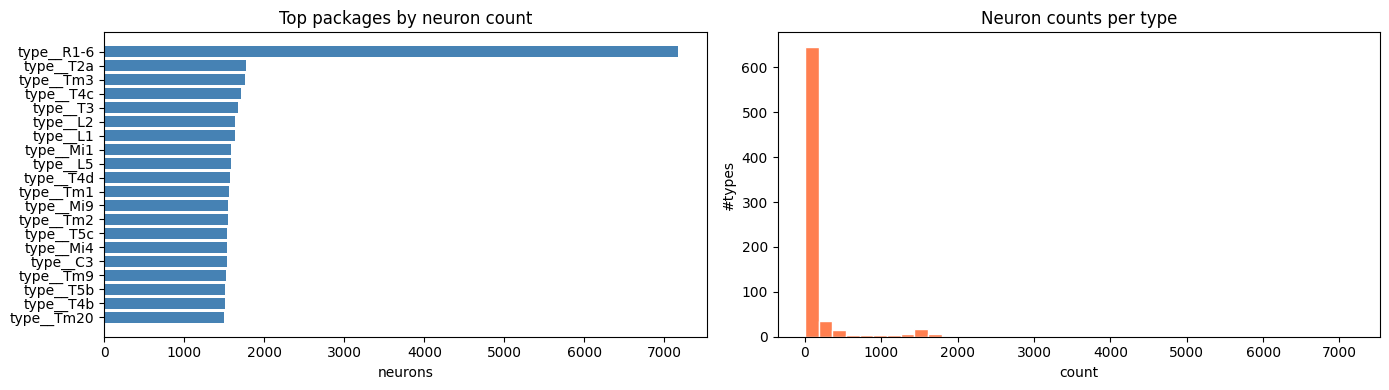

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_pkg = pkg_df.sort_values('neuron_count', ascending=False).head(20)
axes[0].barh(top_pkg['group_name'][::-1], top_pkg['neuron_count'][::-1], color='steelblue')
axes[0].set_title('Top packages by neuron count')
axes[0].set_xlabel('neurons')

axes[1].hist(type_counts.values, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Neuron counts per type')
axes[1].set_xlabel('count')
axes[1].set_ylabel('#types')

plt.tight_layout(); plt.show()

## 3. Build mcHH network and attach morphology packages

In [26]:
t0 = time.time()
net = FAFBMCNetwork.from_preprocessed_with_morphology_packages(
    data_dir=DATA_DIR,
    morphology_package_dir=MORPH_PKG_DIR,
    ion_rules_path=ION_RULES,
    syn_rules_path=SYN_RULES,
    nt_ion_rules_path=NT_ION_RULES,
    neuron_ion_overrides_path=ROOT_ION_OVERRIDES,
    ncomp=NCOMP,
    min_syn_count=MIN_SYN_COUNT,
    dt=DT,
    show_morphology_progress=True,
    progress_every=MORPH_PROGRESS_EVERY,
)

r16_type_mask = torch.tensor(
    np.isin(np.array(net.cell_types, dtype=object), ['R1-6', 'R1-R6']),
    dtype=torch.bool,
    device=net.E_L.device,
)
r16_edge_mask = r16_type_mask[net.pre_idx]
with torch.no_grad():
    if R16_ELEAK_SHIFT_MV != 0.0:
        net.E_L[r16_type_mask] += float(R16_ELEAK_SHIFT_MV)
    if R16_VTH_SHIFT_MV != 0.0:
        net.syn_v_th[r16_edge_mask] += float(R16_VTH_SHIFT_MV)
net.manual_r16_eLeak_shift_mV = float(R16_ELEAK_SHIFT_MV)
net.manual_r16_v_th_shift_mV = float(R16_VTH_SHIFT_MV)
net.manual_r16_neuron_count = int(r16_type_mask.sum().item())
net.manual_r16_edge_count = int(r16_edge_mask.sum().item())
build_elapsed = time.time() - t0

print(); print(f'Build finished in {build_elapsed:.1f}s')
print(net)
print(f"Morphology mode: {getattr(net, 'morphology_graph_mode', 'shared')}")
print(f"Total compartments: {getattr(net, 'total_comp', net.n_comp):,}")
print(f"Max compartments / neuron: {getattr(net, 'n_comp', 0):,}")
print(f"Fallback morphologies: {getattr(net, 'morphology_fallback_count', 0):,}")
print(f'Loaded morphology metadata for {net.loaded_morphology_count:,} neurons')
print(f'Nonzero morphology counts: {(net.morphology_node_counts > 0).sum():,}')
print(f"Root-id overrides used: {getattr(net, 'root_ion_overrides_count', 0):,}")
print(f"Applied R1-6 eLeak shift: {net.manual_r16_eLeak_shift_mV:+.1f} mV across {net.manual_r16_neuron_count:,} neurons")
print(f"Applied R1-6 output v_th shift: {net.manual_r16_v_th_shift_mV:+.1f} mV across {net.manual_r16_edge_count:,} edges")


INFO Morphology packages: 95078 neurons, 309 groups, 1785.4 MB node payload
INFO Loaded CSVs in 0.6s
INFO Mapped 1111323 edges in 0.7s
INFO Synapse lookup done in 6.5s
INFO FAFBMCNetwork: 47291 neurons (2 comp each), 1111323 edges, 4751 photoreceptors [6.6s]
INFO Ion init hierarchy: 5 neurotransmitter defaults, 12 type rules, 0 root overrides


built 5,000/47,291 neuron morphologies, total_comp=149,406, RSS=663.8 MB, elapsed=33.0s
built 10,000/47,291 neuron morphologies, total_comp=306,396, RSS=667.5 MB, elapsed=66.6s
built 15,000/47,291 neuron morphologies, total_comp=451,196, RSS=534.7 MB, elapsed=99.6s
built 20,000/47,291 neuron morphologies, total_comp=602,692, RSS=559.7 MB, elapsed=133.3s
built 25,000/47,291 neuron morphologies, total_comp=751,388, RSS=621.1 MB, elapsed=165.3s
built 30,000/47,291 neuron morphologies, total_comp=904,474, RSS=682.2 MB, elapsed=198.4s
built 35,000/47,291 neuron morphologies, total_comp=1,055,778, RSS=730.1 MB, elapsed=231.3s
built 40,000/47,291 neuron morphologies, total_comp=1,208,994, RSS=780.2 MB, elapsed=264.1s
built 45,000/47,291 neuron morphologies, total_comp=1,356,086, RSS=820.3 MB, elapsed=296.2s
built 47,291/47,291 neuron morphologies, total_comp=1,423,346, RSS=821.5 MB, elapsed=311.7s


INFO Built per-neuron morphology solver for 47291 neurons, 1423346 total compartments, 1 fallbacks [319.8s]
INFO Attached morphology package metadata for 47291/47291 network neurons [319.8s]


per-neuron solver ready: neurons=47,291, total_comp=1,423,346, max_comp=6,746, RSS=1066.7 MB

Build finished in 319.9s
FAFBMCNetwork(n_neurons=47291, total_comp=1423346, max_comp=6746, n_edges=1111323, n_photo=4751, trainable=5840363)
Morphology mode: per_neuron_global_sparse
Total compartments: 1,423,346
Max compartments / neuron: 6,746
Fallback morphologies: 1
Loaded morphology metadata for 47,291 neurons
Nonzero morphology counts: 47,291
Root-id overrides used: 0
Applied R1-6 eLeak shift: -10.0 mV across 3,437 neurons
Applied R1-6 output v_th shift: +8.0 mV across 14,912 edges


## 3b. Ion parameter hierarchy audit

Priority order is: `neurotransmitter default -> neuron type default -> root_id override`.
The table below shows how many neurons used each source in the current build.

,count
nt:acetylcholine,10854
nt:glutamate,5645
type_fallback:T4a,5363
type_fallback:Tm3,4398
nt:gaba,3483
type:R1-6,3437
type_fallback:Mi1,3152
type_fallback:L5,1511
type:Tm3,858
type:Mi1,796


,count
acetylcholine,28982
glutamate,7151
gaba,6000
histamine,4748
unknown,348
da,28
oct,26
ser,8


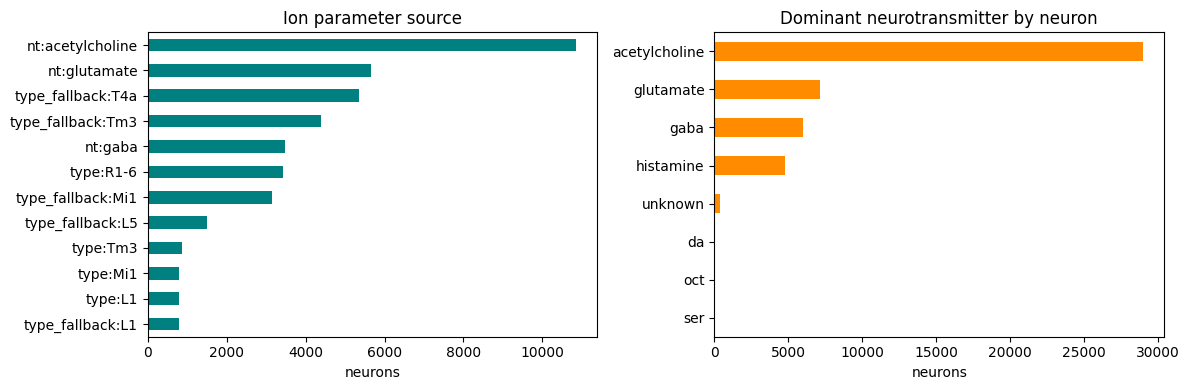

In [27]:
src_counts = pd.Series(net.neuron_param_source).value_counts()
display(src_counts.to_frame('count').head(20))

nt_counts = pd.Series(net.neuron_nt_types).value_counts()
display(nt_counts.to_frame('count'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
src_counts.head(12).sort_values().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Ion parameter source')
axes[0].set_xlabel('neurons')

nt_counts.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Dominant neurotransmitter by neuron')
axes[1].set_xlabel('neurons')
plt.tight_layout(); plt.show()

## 3c. Export per-type parameter audit table

导出每个 `type` 最终使用的参数层级、fallback 目标和 dominant neurotransmitter。

,raw_type,n_neurons,resolved_type,param_source,fallback_target,dominant_nt
0,R1-6,3437,R1-6,type:R1-6,None,histamine
1,T2a,866,T2a,type_fallback:Mi1,Mi1,acetylcholine
2,Tm3,858,Tm3,type:Tm3,None,acetylcholine
3,T4c,842,T4c,type_fallback:T4a,T4a,acetylcholine
4,T3,823,T3,type_fallback:Mi1,Mi1,acetylcholine
5,Mi1,796,Mi1,type:Mi1,None,acetylcholine
6,L1,793,L1,type:L1,None,glutamate
7,L2,791,L2,type_fallback:L1,L1,acetylcholine
8,L5,785,L5,type:L5,None,acetylcholine
9,T4d,777,T4d,type_fallback:T4a,T4a,acetylcholine


Saved: ../logs/optic_lobe_type_param_audit.csv


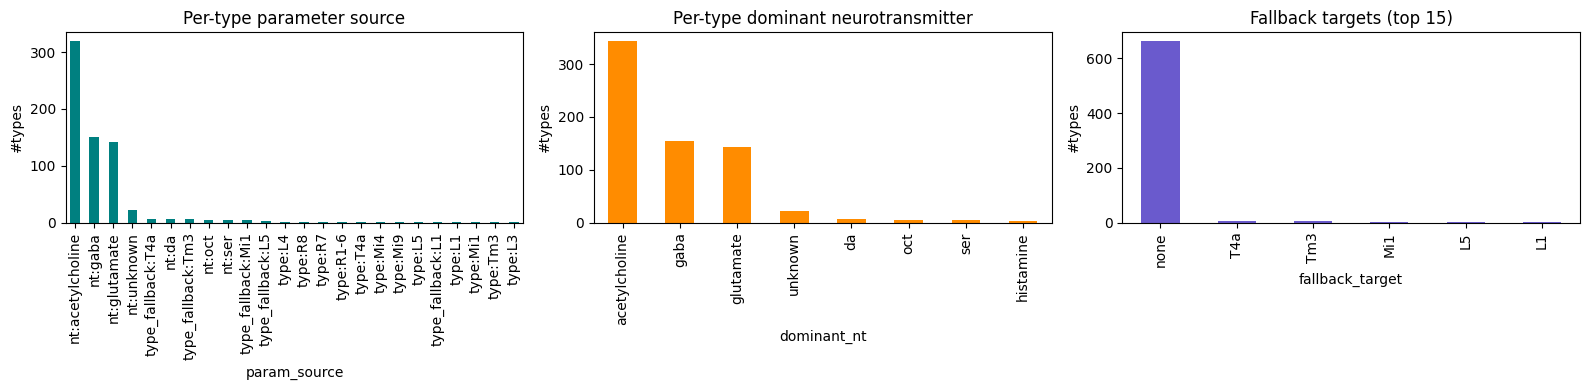

In [28]:
audit_df = pd.DataFrame({
    'root_id': net.root_ids,
    'raw_type': net.raw_cell_types,
    'resolved_type': net.resolved_cell_types,
    'param_source': net.neuron_param_source,
    'fallback_target': net.neuron_fallback_target,
    'dominant_nt': net.neuron_nt_types,
})

def _mode_or_na(s):
    s = s.dropna().astype(str)
    if len(s) == 0:
        return None
    return s.value_counts().idxmax()

type_audit = audit_df.groupby('raw_type', as_index=False).agg(
    n_neurons=('root_id', 'count'),
    resolved_type=('resolved_type', _mode_or_na),
    param_source=('param_source', _mode_or_na),
    fallback_target=('fallback_target', _mode_or_na),
    dominant_nt=('dominant_nt', _mode_or_na),
)

type_audit = type_audit.sort_values(['n_neurons', 'raw_type'], ascending=[False, True]).reset_index(drop=True)
display(type_audit.head(40))

out_csv = '../logs/optic_lobe_type_param_audit.csv'
os.makedirs('../logs', exist_ok=True)
type_audit.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
type_audit['param_source'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Per-type parameter source')
axes[0].set_ylabel('#types')

type_audit['dominant_nt'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Per-type dominant neurotransmitter')
axes[1].set_ylabel('#types')

fb_counts = type_audit['fallback_target'].fillna('none').value_counts().head(15)
fb_counts.plot(kind='bar', ax=axes[2], color='slateblue')
axes[2].set_title('Fallback targets (top 15)')
axes[2].set_ylabel('#types')

plt.tight_layout(); plt.show()

## 3d. Export HH parameter table by neuron and by type

导出当前 build 后每个 neuron / type 实际使用的 HH 参数，方便之后和 response 一起对照。


In [29]:
per_neuron_param_df = pd.DataFrame({
    'root_id': net.root_ids,
    'raw_type': net.raw_cell_types,
    'resolved_type': net.resolved_cell_types,
    'dominant_nt': net.neuron_nt_types,
    'param_source': net.neuron_param_source,
    'fallback_target': net.neuron_fallback_target,
    'gNa_mS_cm2': net.g_Na.detach().cpu().numpy(),
    'gK_mS_cm2': net.g_K.detach().cpu().numpy(),
    'gLeak_mS_cm2': net.g_L.detach().cpu().numpy(),
    'eNa_mV': net.E_Na.detach().cpu().numpy(),
    'eK_mV': net.E_K.detach().cpu().numpy(),
    'eLeak_mV': net.E_L.detach().cpu().numpy(),
    'n_compartment_solver': net.neuron_n_comp.detach().cpu().numpy() if hasattr(net, 'neuron_n_comp') else np.full(net.n_neurons, net.n_comp),
    'n_swc_nodes': net.morphology_node_counts,
})

display(per_neuron_param_df.head())

per_type_param_df = per_neuron_param_df.groupby('raw_type', as_index=False).agg(
    n_neurons=('root_id', 'count'),
    resolved_type=('resolved_type', lambda s: s.astype(str).value_counts().idxmax()),
    dominant_nt=('dominant_nt', lambda s: s.astype(str).value_counts().idxmax()),
    param_source=('param_source', lambda s: s.astype(str).value_counts().idxmax()),
    fallback_target=('fallback_target', lambda s: s.dropna().astype(str).value_counts().idxmax() if s.dropna().shape[0] else None),
    gNa_mS_cm2=('gNa_mS_cm2', 'mean'),
    gK_mS_cm2=('gK_mS_cm2', 'mean'),
    gLeak_mS_cm2=('gLeak_mS_cm2', 'mean'),
    eNa_mV=('eNa_mV', 'mean'),
    eK_mV=('eK_mV', 'mean'),
    eLeak_mV=('eLeak_mV', 'mean'),
    n_compartment_solver_mean=('n_compartment_solver', 'mean'),
    n_swc_nodes_mean=('n_swc_nodes', 'mean'),
)
per_type_param_df = per_type_param_df.sort_values(['n_neurons', 'raw_type'], ascending=[False, True]).reset_index(drop=True)
display(per_type_param_df.head(40))

os.makedirs('../logs', exist_ok=True)
per_neuron_param_df.to_csv('../logs/optic_lobe_per_neuron_hh_params.csv', index=False)
per_type_param_df.to_csv('../logs/optic_lobe_per_type_hh_params.csv', index=False)
print('Saved: ../logs/optic_lobe_per_neuron_hh_params.csv')
print('Saved: ../logs/optic_lobe_per_type_hh_params.csv')


,root_id,raw_type,resolved_type,dominant_nt,param_source,fallback_target,gNa_mS_cm2,gK_mS_cm2,gLeak_mS_cm2,eNa_mV,eK_mV,eLeak_mV,n_compartment_solver,n_swc_nodes
0,720575940596125868,T5c,T5c,acetylcholine,type_fallback:T4a,T4a,2.808765,1.801381,2.230005,50.388248,-77.496460,-51.112808,18,538
1,720575940597856265,Tm16,Tm16,acetylcholine,nt:acetylcholine,None,3.500001,1.900000,1.500000,50.000000,-77.000000,-48.000000,62,1274
2,720575940597944841,Tm7,Tm7,acetylcholine,nt:acetylcholine,None,3.500001,1.900000,1.500000,50.000000,-77.000000,-48.000000,38,1172
3,720575940598267657,TmY15,TmY15,gaba,nt:gaba,None,2.500000,2.200000,1.800000,50.000000,-77.000000,-52.000000,94,1654
4,720575940599333574,Tm1,Tm1,acetylcholine,type_fallback:Tm3,Tm3,8.054436,1.168372,2.132378,51.632076,-76.944099,-47.225616,30,1168


,raw_type,n_neurons,resolved_type,dominant_nt,param_source,fallback_target,gNa_mS_cm2,gK_mS_cm2,gLeak_mS_cm2,eNa_mV,eK_mV,eLeak_mV,n_compartment_solver_mean,n_swc_nodes_mean
0,R1-6,3437,R1-6,histamine,type:R1-6,None,2.950938,2.295049,2.869807,49.484161,-77.288391,-54.950455,11.725924,123.410241
1,T2a,866,T2a,acetylcholine,type_fallback:Mi1,Mi1,7.376991,1.897689,2.055287,49.298958,-76.785042,-45.287323,21.642032,767.103926
2,Tm3,858,Tm3,acetylcholine,type:Tm3,None,8.054436,1.168372,2.132378,51.632076,-76.944099,-47.225616,17.158508,954.589744
3,T4c,842,T4c,acetylcholine,type_fallback:T4a,T4a,2.808765,1.801381,2.230005,50.388248,-77.496460,-51.112808,15.577197,602.958432
4,T3,823,T3,acetylcholine,type_fallback:Mi1,Mi1,7.376990,1.897689,2.055287,49.298958,-76.785042,-45.287319,23.997570,755.951397
5,Mi1,796,Mi1,acetylcholine,type:Mi1,None,7.376990,1.897689,2.055287,49.298954,-76.785042,-45.287319,19.321608,617.952261
6,L1,793,L1,glutamate,type:L1,None,9.938880,2.453703,1.770142,48.056938,-77.108208,-40.670635,18.562421,446.237074
7,L2,791,L2,acetylcholine,type_fallback:L1,L1,9.938880,2.453703,1.770142,48.056938,-77.108208,-40.670635,23.201011,491.390645
8,L5,785,L5,acetylcholine,type:L5,None,9.805357,1.412447,1.424377,46.591835,-76.528976,-43.241062,15.928662,726.166879
9,T4d,777,T4d,acetylcholine,type_fallback:T4a,T4a,2.808765,1.801380,2.230005,50.388248,-77.496460,-51.112808,14.169884,587.136422


Saved: ../logs/optic_lobe_per_neuron_hh_params.csv
Saved: ../logs/optic_lobe_per_type_hh_params.csv


Total neurons: 47,291, edges: 1,111,323, photoreceptors: 4,751
Total compartments: 1,423,346, max compartments/neuron: 6,746
Morphology fallback count: 1
Morphology nodes per neuron: mean=791.4, median=725.0, p95=1676.0


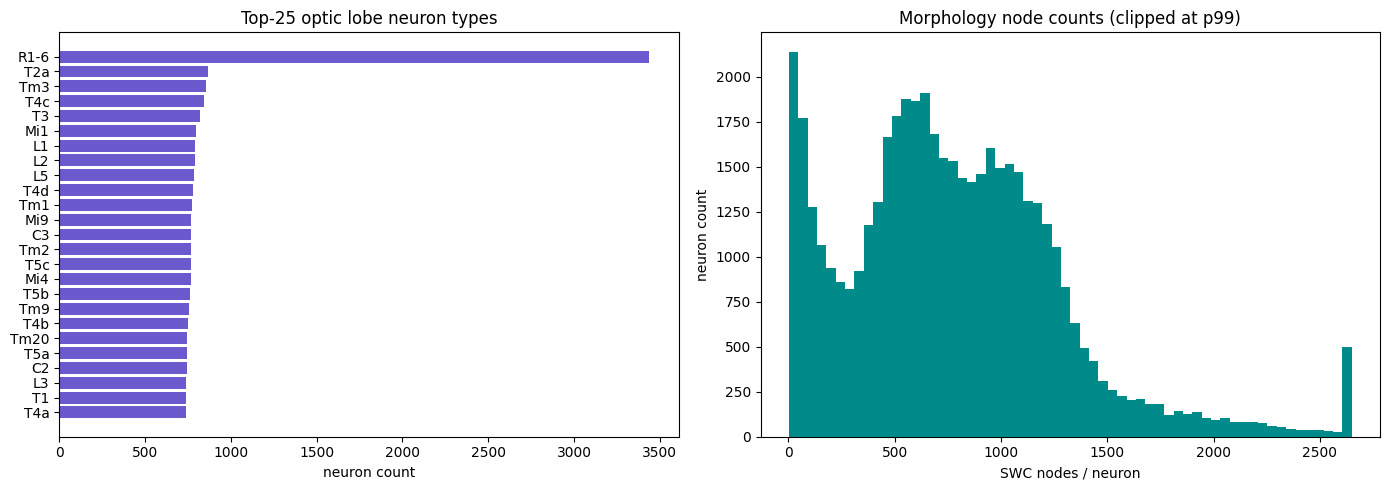

In [30]:
neurons_df = pd.read_csv(DATA_DIR + '/neurons.csv')
tc = net.type_counts()
print(f'Total neurons: {net.n_neurons:,}, edges: {net.n_edges:,}, photoreceptors: {net.input_mask.sum().item():,}')
print(f"Total compartments: {getattr(net, 'total_comp', net.n_comp):,}, max compartments/neuron: {net.n_comp:,}")
print(f"Morphology fallback count: {getattr(net, 'morphology_fallback_count', 0):,}")

morph_counts = pd.Series(net.morphology_node_counts)
nonzero_morph = morph_counts[morph_counts > 0]
print(f'Morphology nodes per neuron: mean={nonzero_morph.mean():.1f}, median={nonzero_morph.median():.1f}, p95={nonzero_morph.quantile(0.95):.1f}')

# Visualization is intentionally aggregated: plotting all neurons is too dense and too slow.
top_types = sorted(tc.items(), key=lambda x: -x[1])[:25]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([k for k, _ in top_types][::-1], [v for _, v in top_types][::-1], color='slateblue')
axes[0].set_title('Top-25 optic lobe neuron types')
axes[0].set_xlabel('neuron count')

axes[1].hist(nonzero_morph.clip(upper=nonzero_morph.quantile(0.99)), bins=60, color='darkcyan')
axes[1].set_title('Morphology node counts (clipped at p99)')
axes[1].set_xlabel('SWC nodes / neuron')
axes[1].set_ylabel('neuron count')
plt.tight_layout(); plt.show()


## 4. Sample morphology reads with progress + memory reporting

Only sample a small set for inspection. Full-neuron morphology visualization is not useful at optic-lobe scale.


In [31]:
sample_types = ['R1-6', 'L1', 'Mi1', 'Tm3', 'T4a', 'T5a']
sample_morphs = []
for morph in loader.iter_neurons(types=sample_types, limit=MORPH_SAMPLE_LIMIT, show_progress=True, progress_every=100):
    sample_morphs.append(morph)

print(f'Loaded {len(sample_morphs)} sample morphologies')
if sample_morphs:
    print('First sample:', sample_morphs[0].root_id, sample_morphs[0].neuron_type, sample_morphs[0].node_count)


Load morphologies:   0%|          | 0/300 [00:00<?, ?neuron/s]

loaded 100/300 neurons, nodes=32,225, RSS=471.3 MB, elapsed=0.0s
loaded 200/300 neurons, nodes=63,174, RSS=471.3 MB, elapsed=0.0s
loaded 300/300 neurons, nodes=94,260, RSS=471.5 MB, elapsed=0.0s
Loaded 300 sample morphologies
First sample: 720575940600322965 L1 354


,root_id,type,node_count,package
0,720575940600322965,L1,354,type__L1.bin
1,720575940602857696,L1,254,type__L1.bin
2,720575940604525792,L1,172,type__L1.bin
3,720575940604635616,L1,101,type__L1.bin
4,720575940604738016,L1,68,type__L1.bin


,type,n,node_mean,node_median,node_p95
0,L1,300,314.2,177.5,938.4


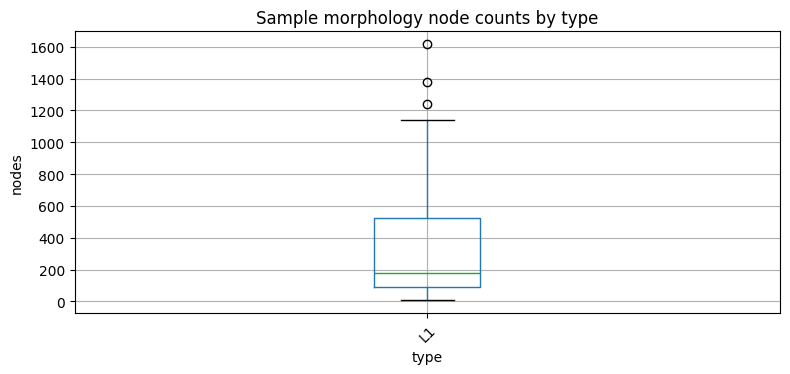

In [32]:
sample_df = pd.DataFrame({
    'root_id': [m.root_id for m in sample_morphs],
    'type': [m.neuron_type for m in sample_morphs],
    'node_count': [m.node_count for m in sample_morphs],
    'package': [m.package for m in sample_morphs],
})
display(sample_df.head())

type_summary = sample_df.groupby('type', as_index=False).agg(
    n=('root_id', 'count'),
    node_mean=('node_count', 'mean'),
    node_median=('node_count', 'median'),
    node_p95=('node_count', lambda x: x.quantile(0.95)),
)
display(type_summary.sort_values('node_median', ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
sample_df.boxplot(column='node_count', by='type', ax=ax, rot=45)
ax.set_title('Sample morphology node counts by type')
ax.set_ylabel('nodes')
plt.suptitle('')
plt.tight_layout(); plt.show()


## 5. Stability-first flash sanity check

Run a short no-grad simulation first and extend only until the network appears stable. This avoids storing every compartment and only records soma voltages. If `R1-6` is weak but stable, rerun with `STRONG_SANITY_I_AMP`.


In [33]:
SANITY_I_AMP = 300.0

In [34]:
def run_flash_sanity(
    net,
    amp=SANITY_I_AMP,
    t_pre=SANITY_T_PRE,
    t_on=SANITY_T_ON,
    t_off=SANITY_T_OFF,
    stable_seconds=SANITY_STABILITY_SECONDS,
    dt=DT,
    progress_every=SANITY_PROGRESS_EVERY,
    stop_on_nan=True,
    r16_synapse_gain=R16_SYNAPSE_GAIN,
):
    import time as _time

    requested_steps = int((t_pre + t_on + t_off) / dt)
    max_steps_by_time = max(1, int(stable_seconds / dt))
    T_steps = min(requested_steps, max_steps_by_time)
    t_on_s = min(int(t_pre / dt), T_steps)
    t_on_e = min(int((t_pre + t_on) / dt), T_steps)

    n_photo = int(net.input_mask.sum().item())
    photo_indices = torch.where(net.input_mask)[0]
    x_photo = torch.zeros(1, T_steps, n_photo)
    if t_on_e > t_on_s:
        x_photo[:, t_on_s:t_on_e, :] = amp

    x_full = torch.zeros(1, T_steps, net.n_neurons)
    x_full[:, :, photo_indices] = x_photo

    print(f'Flash sanity: amp={amp}, steps={T_steps}, dt={dt}, simulated_ms={T_steps * dt:.1f}, n_photo={n_photo:,}, r16_synapse_gain={r16_synapse_gain}')
    print(f'Network: neurons={net.n_neurons:,}, edges={net.n_edges:,}, total_comp={getattr(net, "total_comp", net.n_comp):,}')

    traces = []
    t0 = _time.time()
    with torch.no_grad():
        net._cache_step_tensors(max_batch=1)
        original_syn_gS_w = net._syn_gS_w.clone()
        if r16_synapse_gain != 1.0:
            r16_mask = torch.tensor([ct in ('R1-6', 'R1-R6') for ct in net.cell_types], device=net.pre_idx.device)
            r16_edge_mask = r16_mask[net.pre_idx]
            net._syn_gS_w[r16_edge_mask] = net._syn_gS_w[r16_edge_mask] * float(r16_synapse_gain)

        state = net.init_state(1, device=x_full.device)
        for t_i in range(T_steps):
            if getattr(net, 'ragged_mode', False):
                I_ext = torch.zeros(1, net.total_comp, dtype=torch.float64, device=x_full.device)
                I_ext[:, net.soma_comp_idx] = x_full[:, t_i].double()
                state = net._step(state, I_ext, dt)
                soma_v = state['V'][:, net.soma_comp_idx].float()
            else:
                I_ext = torch.zeros(1, net.n_neurons, net.n_comp, dtype=torch.float64, device=x_full.device)
                I_ext[:, :, 0] = x_full[:, t_i].double()
                state = net._step(state, I_ext, dt)
                soma_v = state['V'][:, :, 0].float()

            traces.append(soma_v.cpu())
            if torch.isnan(soma_v).any():
                print(f'NaN detected at step {t_i + 1}; stopping early.')
                if stop_on_nan:
                    break

            if (t_i + 1) % max(progress_every, 1) == 0 or (t_i + 1) == T_steps:
                print(f'  step {t_i + 1:,}/{T_steps:,}, elapsed={_time.time() - t0:.1f}s')

        net._syn_gS_w = original_syn_gS_w

    V = torch.stack(traces, dim=1)
    summary = {
        'amp': amp,
        'steps_run': V.shape[1],
        'simulated_ms': V.shape[1] * dt,
        'output_shape': tuple(V.shape),
        'v_min': float(V.min().item()),
        'v_max': float(V.max().item()),
        'has_nan': bool(torch.isnan(V).any().item()),
        'elapsed_s': _time.time() - t0,
        'r16_synapse_gain': float(r16_synapse_gain),
    }
    return V, summary, {'t_on_s': t_on_s, 't_on_e': t_on_e, 'dt': dt, 'amp': amp, 'r16_synapse_gain': r16_synapse_gain}

V, sanity_summary, flash_meta = run_flash_sanity(net, amp=SANITY_I_AMP)
print(sanity_summary)

# If equilibration helps but R1-6 output is still too weak, try a stronger photoreceptor drive or a moderate R1-6 synapse gain.
# V_strong, sanity_summary_strong, flash_meta_strong = run_flash_sanity(net, amp=STRONG_SANITY_I_AMP)
# V_r16boost, sanity_summary_r16boost, flash_meta_r16boost = run_flash_sanity(net, amp=SANITY_I_AMP, r16_synapse_gain=1.5)


Flash sanity: amp=300.0, steps=800, dt=0.1, simulated_ms=80.0, n_photo=4,751, r16_synapse_gain=1.0
Network: neurons=47,291, edges=1,111,323, total_comp=1,423,346
  step 50/800, elapsed=38.8s
  step 100/800, elapsed=76.0s
  step 150/800, elapsed=113.2s
  step 200/800, elapsed=150.1s
  step 250/800, elapsed=187.4s
  step 300/800, elapsed=224.6s
  step 350/800, elapsed=261.5s
  step 400/800, elapsed=298.8s
  step 450/800, elapsed=335.7s
  step 500/800, elapsed=372.7s
  step 550/800, elapsed=409.9s
  step 600/800, elapsed=447.5s
  step 650/800, elapsed=484.5s
  step 700/800, elapsed=521.5s
  step 750/800, elapsed=558.7s
  step 800/800, elapsed=595.9s
{'amp': 300.0, 'steps_run': 800, 'simulated_ms': 80.0, 'output_shape': (1, 800, 47291), 'v_min': -120.0, 'v_max': 80.0, 'has_nan': False, 'elapsed_s': 595.9768290519714, 'r16_synapse_gain': 1.0}


,type,n,baseline_mV,on_mV,off_mV,delta_on_minus_base,peak_max_mV,peak_min_mV
0,R1-6,3437,-45.456558,-16.498024,-45.744843,28.958534,-9.771563,-48.373615
1,L1,793,-40.026443,-42.493343,-40.679291,-2.466900,-37.916584,-43.501076
2,L3,738,-46.671730,-47.531708,-47.010220,-0.859978,-45.501881,-47.596848
3,L5,785,-41.891090,-41.735840,-41.703514,0.155251,-40.473286,-42.679821
4,Mi1,796,-45.448029,-45.440327,-45.408413,0.007702,-42.873795,-45.663246
5,Mi9,770,-45.250420,-45.159428,-45.167267,0.090992,-44.909817,-45.678291
6,Tm3,858,-45.755753,-45.683849,-45.654171,0.071903,-45.527752,-46.043575
7,T4a,737,-48.817909,-48.751698,-48.751186,0.066212,-48.742622,-49.398666
8,T5a,743,-49.046627,-48.956562,-48.956562,0.090065,-48.844074,-49.317532


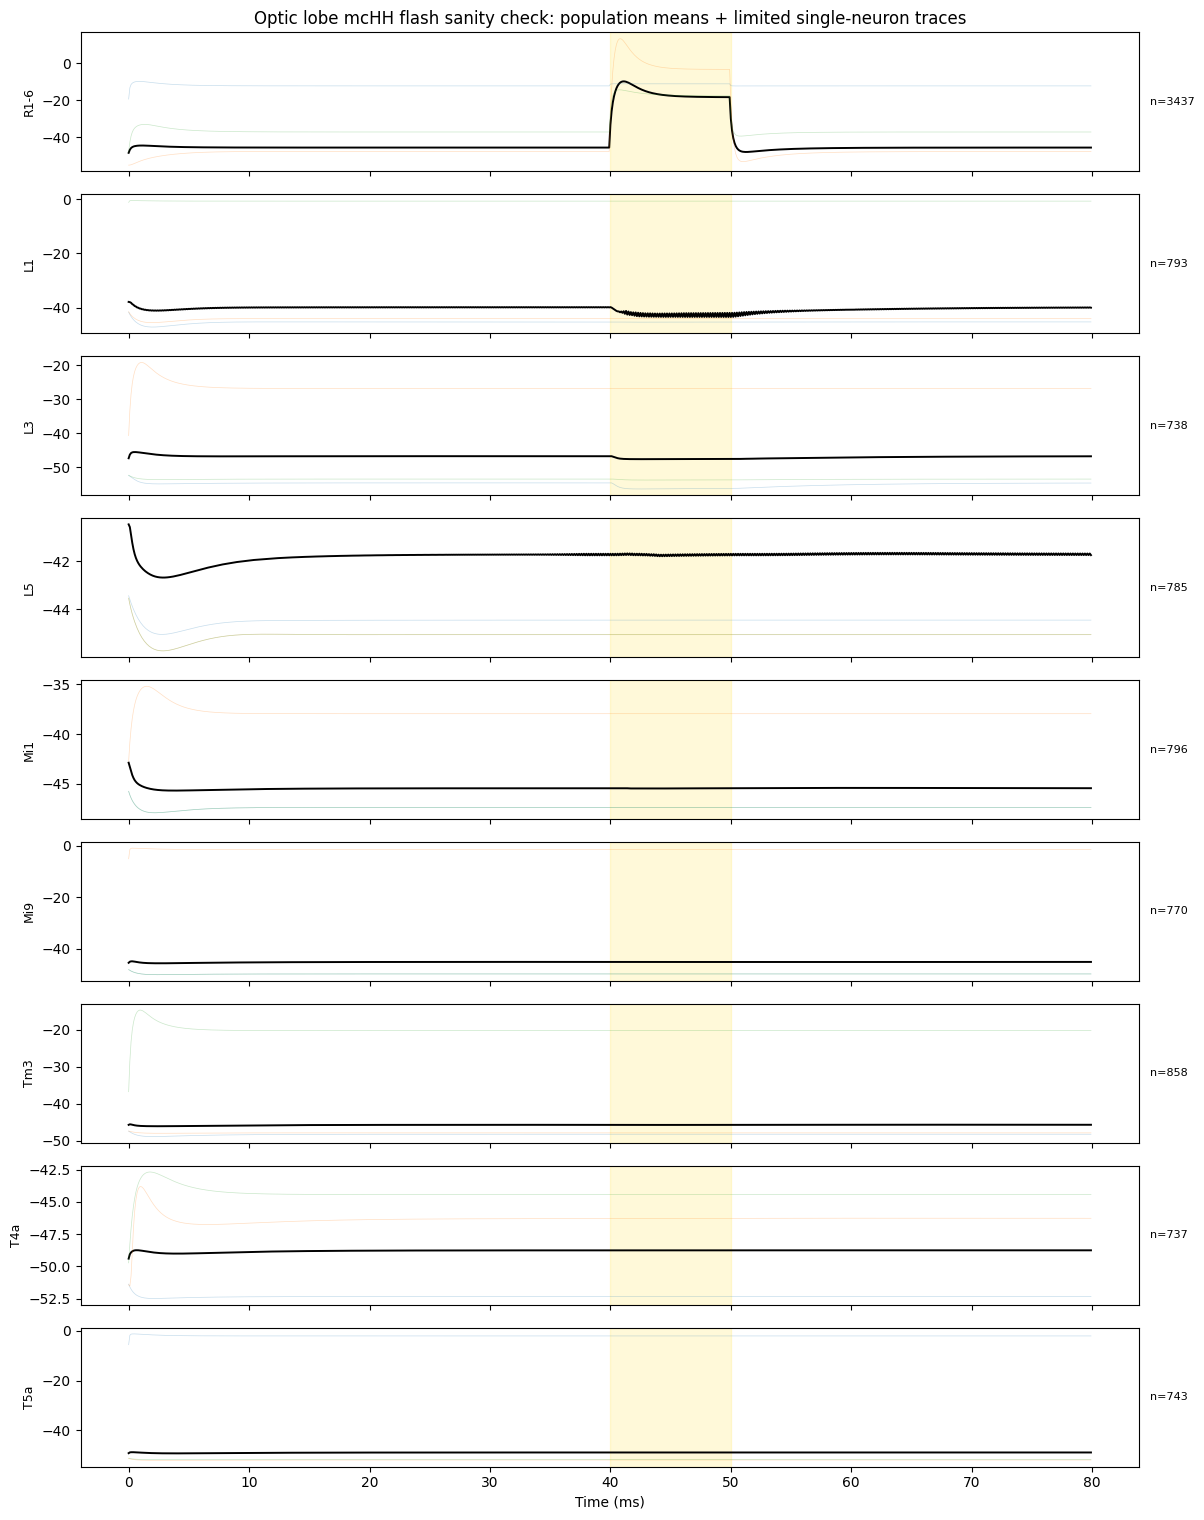

In [35]:
def summarize_flash_by_type(V, meta, show_types=SUMMARY_TYPES):
    t_on_s = meta['t_on_s']
    t_on_e = meta['t_on_e']
    rows = []
    for ct in show_types:
        idx = net.get_indices_by_type(ct)
        if not idx:
            continue
        vm = V[0, :, idx].mean(dim=1)
        base = vm[:t_on_s].mean().item() if t_on_s > 0 else float('nan')
        on = vm[t_on_s:t_on_e].mean().item() if t_on_e > t_on_s else float('nan')
        off = vm[t_on_e:].mean().item() if t_on_e < V.shape[1] else float('nan')
        rows.append({
            'type': ct,
            'n': len(idx),
            'baseline_mV': base,
            'on_mV': on,
            'off_mV': off,
            'delta_on_minus_base': on - base,
            'peak_max_mV': vm.max().item(),
            'peak_min_mV': vm.min().item(),
        })
    return pd.DataFrame(rows)

flash_type_summary = summarize_flash_by_type(V, flash_meta)
display(flash_type_summary)

t_ms = np.arange(V.shape[1]) * flash_meta['dt']
fig, axes = plt.subplots(len(SUMMARY_TYPES), 1, figsize=(12, 1.7 * len(SUMMARY_TYPES)), sharex=True)
if len(SUMMARY_TYPES) == 1:
    axes = [axes]

for ax, ct in zip(axes, SUMMARY_TYPES):
    idx = net.get_indices_by_type(ct)
    ax.set_ylabel(ct, fontsize=9)
    if not idx:
        continue

    # Population mean is the main scalable visualization.
    vm = V[0, :, idx].mean(dim=1).numpy()
    ax.plot(t_ms, vm, lw=1.4, color='black', label='population mean')

    # A few individual traces can reveal heterogeneity without overplotting thousands of neurons.
    for j in idx[:MAX_SINGLE_NEURON_TRACES_PER_TYPE]:
        ax.plot(t_ms, V[0, :, j].numpy(), lw=0.5, alpha=0.25)

    ax.axvspan(
        flash_meta['t_on_s'] * flash_meta['dt'],
        flash_meta['t_on_e'] * flash_meta['dt'],
        color='gold', alpha=0.15,
    )
    ax.text(1.01, 0.5, f'n={len(idx)}', transform=ax.transAxes, va='center', fontsize=8)

axes[-1].set_xlabel('Time (ms)')
axes[0].set_title('Optic lobe mcHH flash sanity check: population means + limited single-neuron traces')
plt.tight_layout(); plt.show()


## 5b. Example single-neuron responses

除了 population mean，也直接看少量具体 neuron 的轨迹。这里每个 type 只抽少数几个例子，避免把数千个 neuron 全部画出来。


,type,neuron_idx,root_id,baseline_mV,on_mV,off_mV,peak_max_mV,peak_min_mV
0,R1-6,26,720575940601049097,-12.047363,-11.099548,-12.217783,-9.791432,-19.327120
1,R1-6,402,720575940605160550,-48.113983,-0.564691,-48.175484,13.293434,-55.027916
2,R1-6,524,720575940605444576,-36.804184,-16.915373,-37.310509,-14.334023,-48.031555
3,L1,48,720575940602857696,-45.464920,-45.378155,-45.322281,-41.708473,-47.214520
4,L1,273,720575940604747953,-44.221424,-44.125900,-44.112450,-41.547043,-45.578278
5,L1,356,720575940605032364,-0.657418,-0.667333,-0.667327,-0.458710,-1.117877
6,L3,308,720575940604889568,-54.595821,-56.193886,-55.060555,-52.390144,-56.370800
7,L3,443,720575940605268140,-26.340574,-26.798033,-26.798033,-19.135168,-40.657768
8,L3,445,720575940605273772,-53.464912,-53.699238,-53.521709,-52.341385,-53.744778
9,L5,121,720575940603923116,-44.504204,-44.442993,-44.442829,-43.430557,-45.035877


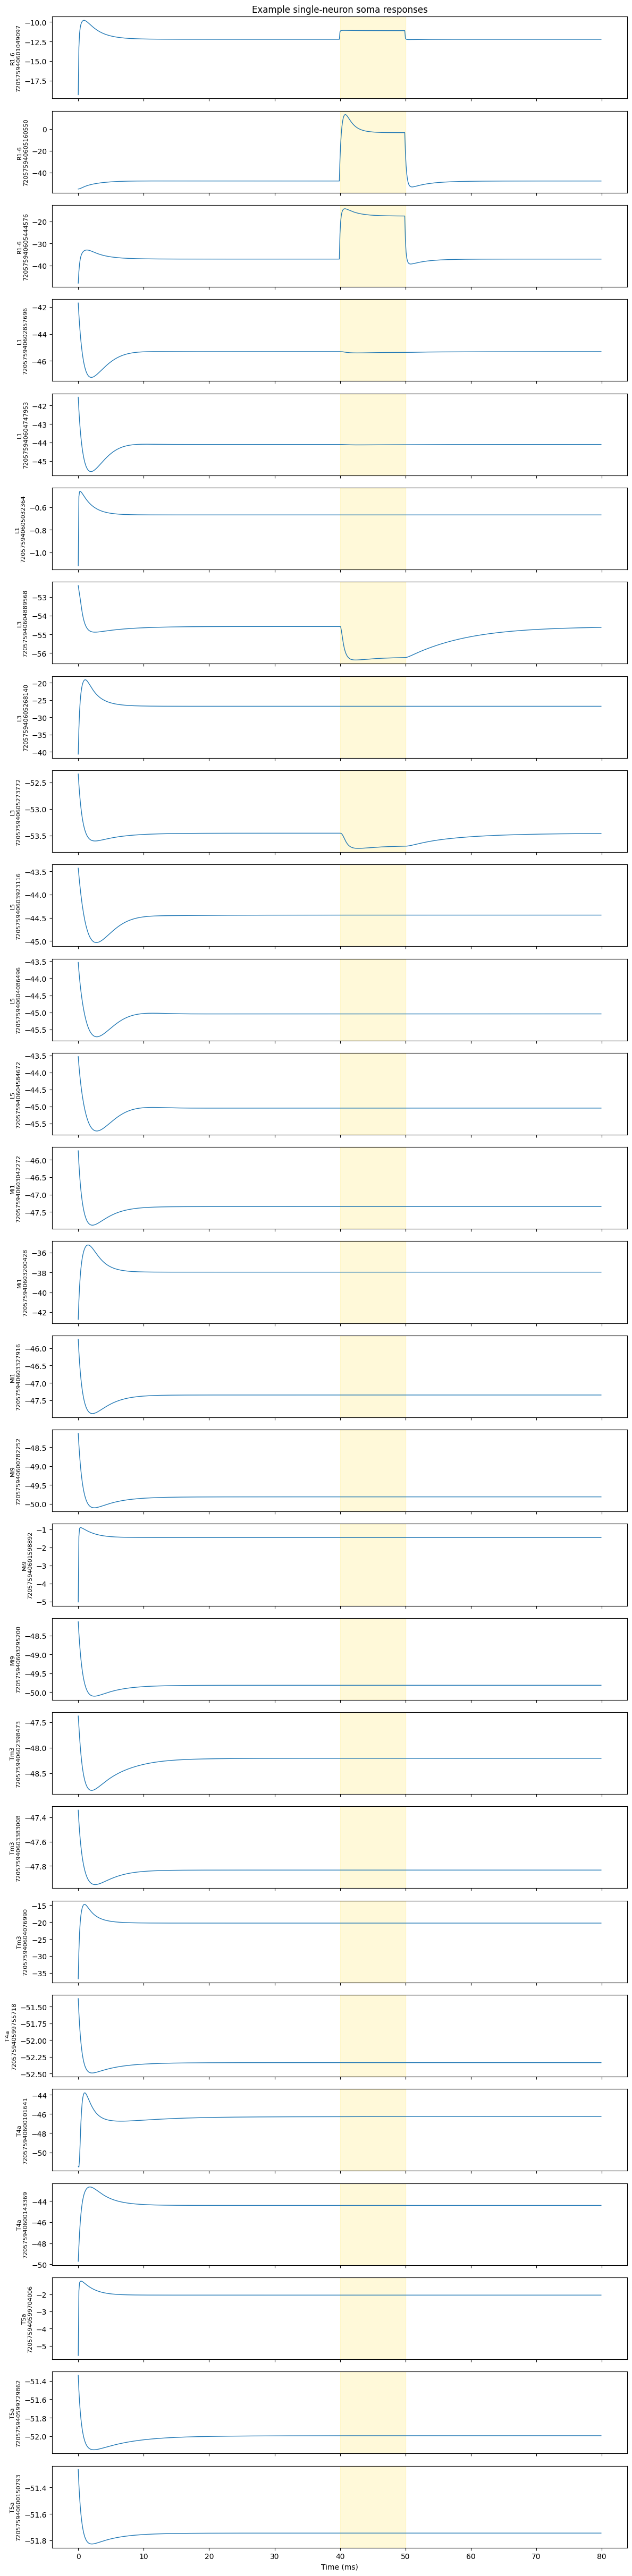

In [36]:
example_rows = []
for ct in SUMMARY_TYPES:
    idx = net.get_indices_by_type(ct)[:MAX_SINGLE_NEURON_TRACES_PER_TYPE]
    for j in idx:
        trace = V[0, :, j]
        example_rows.append({
            'type': ct,
            'neuron_idx': int(j),
            'root_id': int(net.root_ids[j]) if hasattr(net, 'root_ids') else j,
            'baseline_mV': float(trace[:flash_meta['t_on_s']].mean().item()) if flash_meta['t_on_s'] > 0 else float('nan'),
            'on_mV': float(trace[flash_meta['t_on_s']:flash_meta['t_on_e']].mean().item()) if flash_meta['t_on_e'] > flash_meta['t_on_s'] else float('nan'),
            'off_mV': float(trace[flash_meta['t_on_e']:].mean().item()) if flash_meta['t_on_e'] < trace.shape[0] else float('nan'),
            'peak_max_mV': float(trace.max().item()),
            'peak_min_mV': float(trace.min().item()),
        })

example_df = pd.DataFrame(example_rows)
display(example_df)

if len(example_rows) > 0:
    fig, axes = plt.subplots(len(example_rows), 1, figsize=(12, 1.8 * len(example_rows)), sharex=True)
    if len(example_rows) == 1:
        axes = [axes]

    for ax, row in zip(axes, example_rows):
        j = row['neuron_idx']
        trace = V[0, :, j].numpy()
        ax.plot(t_ms, trace, lw=1.0)
        ax.axvspan(
            flash_meta['t_on_s'] * flash_meta['dt'],
            flash_meta['t_on_e'] * flash_meta['dt'],
            color='gold', alpha=0.15,
        )
        ax.set_ylabel(f"{row['type']}\n{row['root_id']}", fontsize=8)

    axes[-1].set_xlabel('Time (ms)')
    axes[0].set_title('Example single-neuron soma responses')
    plt.tight_layout(); plt.show()


## 5d. Key pathway synapse audit

针对 optic lobe 关键通路，直接导出 edge-level synapse 参数，并结合当前 baseline voltage 估计这些 synapse 在刺激前的开关程度。


In [37]:
key_pathway_pairs = [
    ('R1-6', 'L1'),
    ('R1-6', 'L3'),
    ('R8', 'L1'),
    ('L1', 'Mi1'),
    ('L1', 'Tm3'),
    ('L3', 'Mi1'),
    ('L3', 'Mi9'),
    ('L5', 'L1'),
    ('L5', 'Mi1'),
    ('L5', 'Tm3'),
    ('Mi1', 'T4a'),
    ('Mi4', 'T4a'),
    ('Mi9', 'T4a'),
    ('Tm3', 'T4a'),
]

base_window = slice(0, flash_meta['t_on_s'])
base_soma = V[0, base_window].mean(dim=0) if flash_meta['t_on_s'] > 0 else V[0, 0]

edge_audit = pd.DataFrame({
    'pre_idx': net.pre_idx.detach().cpu().numpy(),
    'post_idx': net.post_idx.detach().cpu().numpy(),
    'pre_type': np.array(net.cell_types)[net.pre_idx.detach().cpu().numpy()],
    'post_type': np.array(net.cell_types)[net.post_idx.detach().cpu().numpy()],
    'pre_root_id': net.root_ids[net.pre_idx.detach().cpu().numpy()],
    'post_root_id': net.root_ids[net.post_idx.detach().cpu().numpy()],
    'syn_count': net.syn_count.detach().cpu().numpy(),
    'gS_mS_cm2': net.syn_gS.detach().cpu().numpy(),
    'e_syn_mV': net.syn_e_syn.detach().cpu().numpy(),
    'v_th_mV': net.syn_v_th.detach().cpu().numpy(),
    'k_minus': net.syn_k_minus.detach().cpu().numpy(),
    'delta_mV': net.syn_delta.detach().cpu().numpy(),
    'pre_baseline_mV': base_soma[net.pre_idx].detach().cpu().numpy(),
    'post_baseline_mV': base_soma[net.post_idx].detach().cpu().numpy(),
})
edge_audit['s_inf_baseline'] = 1.0 / (1.0 + np.exp((edge_audit['v_th_mV'] - edge_audit['pre_baseline_mV']) / edge_audit['delta_mV'].clip(lower=1e-3)))
edge_audit['tau_s_baseline_ms'] = (1.0 - edge_audit['s_inf_baseline']) / edge_audit['k_minus'].clip(lower=1e-6)
edge_audit['pair'] = list(zip(edge_audit['pre_type'], edge_audit['post_type']))
edge_audit['is_r16_output'] = edge_audit['pre_type'].isin(['R1-6', 'R1-R6'])

key_edge_audit = edge_audit[edge_audit['pair'].isin(key_pathway_pairs)].copy()
key_edge_summary = key_edge_audit.groupby(['pre_type', 'post_type'], as_index=False).agg(
    n_edges=('pair', 'size'),
    syn_count_mean=('syn_count', 'mean'),
    gS_mS_cm2_mean=('gS_mS_cm2', 'mean'),
    e_syn_mV_mean=('e_syn_mV', 'mean'),
    v_th_mV_mean=('v_th_mV', 'mean'),
    k_minus_mean=('k_minus', 'mean'),
    delta_mV_mean=('delta_mV', 'mean'),
    pre_baseline_mV_mean=('pre_baseline_mV', 'mean'),
    post_baseline_mV_mean=('post_baseline_mV', 'mean'),
    s_inf_baseline_mean=('s_inf_baseline', 'mean'),
    s_inf_baseline_median=('s_inf_baseline', 'median'),
    tau_s_baseline_ms_mean=('tau_s_baseline_ms', 'mean'),
)
key_edge_summary = key_edge_summary.sort_values(['pre_type', 'post_type']).reset_index(drop=True)

r16_edge_audit = edge_audit[edge_audit['is_r16_output']].copy()
r16_edge_summary = r16_edge_audit.groupby(['pre_type', 'post_type'], as_index=False).agg(
    n_edges=('pair', 'size'),
    syn_count_mean=('syn_count', 'mean'),
    gS_mS_cm2_mean=('gS_mS_cm2', 'mean'),
    e_syn_mV_mean=('e_syn_mV', 'mean'),
    v_th_mV_mean=('v_th_mV', 'mean'),
    k_minus_mean=('k_minus', 'mean'),
    delta_mV_mean=('delta_mV', 'mean'),
    pre_baseline_mV_mean=('pre_baseline_mV', 'mean'),
    post_baseline_mV_mean=('post_baseline_mV', 'mean'),
    s_inf_baseline_mean=('s_inf_baseline', 'mean'),
    s_inf_baseline_median=('s_inf_baseline', 'median'),
    tau_s_baseline_ms_mean=('tau_s_baseline_ms', 'mean'),
)
r16_edge_summary = r16_edge_summary.sort_values('post_type').reset_index(drop=True)

print('Key pathway synapse summary')
display(key_edge_summary)
print('All R1-6 output synapses')
display(r16_edge_summary)
print('Example R1-6 output edges')
display(r16_edge_audit.sort_values(['post_type', 'post_root_id']).head(40))

key_edge_summary.to_csv('../logs/optic_lobe_key_pathway_synapse_audit.csv', index=False)
key_edge_audit.to_csv('../logs/optic_lobe_key_pathway_synapse_edges.csv', index=False)
r16_edge_summary.to_csv('../logs/optic_lobe_r16_output_synapse_audit.csv', index=False)
r16_edge_audit.to_csv('../logs/optic_lobe_r16_output_synapse_edges.csv', index=False)
print('Saved: ../logs/optic_lobe_key_pathway_synapse_audit.csv')
print('Saved: ../logs/optic_lobe_key_pathway_synapse_edges.csv')
print('Saved: ../logs/optic_lobe_r16_output_synapse_audit.csv')
print('Saved: ../logs/optic_lobe_r16_output_synapse_edges.csv')


Key pathway synapse summary


,pre_type,post_type,n_edges,syn_count_mean,gS_mS_cm2_mean,e_syn_mV_mean,v_th_mV_mean,k_minus_mean,delta_mV_mean,pre_baseline_mV_mean,post_baseline_mV_mean,s_inf_baseline_mean,s_inf_baseline_median,tau_s_baseline_ms_mean
0,L1,Mi1,811,121.506783,0.819002,-73.131195,-50.060799,0.109991,3.026100,-40.060177,-45.440575,0.831025,0.838756,1.536265
1,L1,Tm3,3385,20.247562,0.598719,-72.636246,-50.060795,0.109991,3.026100,-39.824829,-45.778633,0.832555,0.838658,1.522363
2,L3,Mi1,748,18.779411,0.298823,-1.126880,-52.744278,0.095662,3.350154,-46.374153,-45.780640,0.540681,0.440867,4.801449
3,L3,Mi9,883,61.770103,0.639386,0.375568,-52.744282,0.095663,3.350154,-46.479771,-45.142944,0.538043,0.440407,4.829025
4,L5,L1,795,33.397484,0.334285,-0.569884,-44.619507,0.129946,3.904476,-41.798923,-40.062553,0.475745,0.469445,4.034401
5,L5,Mi1,993,38.210472,0.266811,-1.126880,-44.619507,0.129946,3.904476,-41.667606,-45.513222,0.478888,0.469445,4.010215
6,L5,Tm3,3144,13.572519,0.314870,-0.695274,-44.619507,0.129946,3.904476,-41.489033,-45.654984,0.479353,0.469445,4.006632
7,Mi1,T4a,2655,16.200001,0.466792,-0.214565,-47.077271,0.089959,3.425398,-45.395470,-48.740791,0.456596,0.476958,6.040556
8,Mi4,T4a,609,7.357964,0.768977,-71.605972,-52.590805,0.109026,3.264412,-46.824554,-48.954498,0.627669,0.546858,3.415070
9,Mi9,T4a,787,8.559085,0.697489,-71.605972,-44.184505,0.066598,4.389192,-45.228874,-49.026291,0.340110,0.216254,9.908522


All R1-6 output synapses


,pre_type,post_type,n_edges,syn_count_mean,gS_mS_cm2_mean,e_syn_mV_mean,v_th_mV_mean,k_minus_mean,delta_mV_mean,pre_baseline_mV_mean,post_baseline_mV_mean,s_inf_baseline_mean,s_inf_baseline_median,tau_s_baseline_ms_mean
0,R1-6,C2,5,5.400000,0.400000,-72.000000,-52.000000,0.100000,3.000000,-34.716305,-45.652367,0.538178,0.235426,4.618219
1,R1-6,C3,12,5.250000,0.400000,-72.000000,-52.000000,0.100000,3.000000,-39.018909,-42.927212,0.579511,0.417818,4.204894
2,R1-6,L1,3422,42.492111,0.904157,-69.640152,-37.344635,0.117965,3.590984,-45.425289,-39.772305,0.239804,0.006680,6.444248
3,R1-6,L2,3433,52.004368,0.400000,-72.000000,-52.000000,0.100000,3.000000,-45.503178,-42.828129,0.501237,0.248744,4.987628
4,R1-6,L3,3203,24.514517,0.858069,-68.045479,-37.344635,0.117965,3.590984,-45.434845,-46.448906,0.240304,0.006690,6.440014
5,R1-6,L4,9,9.555555,0.400000,-72.000000,-52.000000,0.100000,3.000000,-34.579567,-49.181950,0.658695,0.998255,3.413055
6,R1-6,L5,3,10.333333,0.400000,-72.000000,-52.000000,0.100000,3.000000,-38.622402,-48.362232,0.494041,0.246846,5.059587
7,R1-6,Lai,3589,23.755085,0.400000,-72.000000,-52.000000,0.100000,3.000000,-45.265663,-45.049679,0.504119,0.250136,4.958811
8,R1-6,R1-6,190,6.510526,0.400000,-72.000000,-52.000000,0.100000,3.000000,-45.785286,-45.213634,0.490278,0.252693,5.097218
9,R1-6,R7,2,6.500000,0.400000,-72.000000,-52.000000,0.100000,3.000000,-30.482035,-46.298172,0.637386,0.637386,3.626143


Example R1-6 output edges


,pre_idx,post_idx,pre_type,post_type,pre_root_id,post_root_id,syn_count,gS_mS_cm2,e_syn_mV,v_th_mV,k_minus,delta_mV,pre_baseline_mV,post_baseline_mV,s_inf_baseline,tau_s_baseline_ms,pair,is_r16_output
130887,4994,16916,R1-6,C2,720575940612747889,720575940621571199,6.0,0.400000,-72.000000,-52.000000,0.100000,3.000000,-0.668364,-45.097305,1.000000,3.706680e-07,"(R1-6, C2)",True
639907,41616,17115,R1-6,C2,720575940637454222,720575940621660144,6.0,0.400000,-72.000000,-52.000000,0.100000,3.000000,-55.661396,-44.304733,0.227855,7.721454e+00,"(R1-6, C2)",True
873866,8931,32625,R1-6,C2,720575940616297119,720575940629985128,5.0,0.400000,-72.000000,-52.000000,0.100000,3.000000,-6.052428,-48.665173,1.000000,2.230528e-06,"(R1-6, C2)",True
103212,42976,36394,R1-6,C2,720575940639165156,720575940632224908,5.0,0.400000,-72.000000,-52.000000,0.100000,3.000000,-55.665565,-45.097294,0.227610,7.723899e+00,"(R1-6, C2)",True
389527,13539,39563,R1-6,C2,720575940619750966,720575940634966463,5.0,0.400000,-72.000000,-52.000000,0.100000,3.000000,-55.533768,-45.097343,0.235426,7.645741e+00,"(R1-6, C2)",True
473554,28446,1541,R1-6,C3,720575940627721624,720575940607471538,6.0,0.400000,-72.000000,-52.000000,0.100000,3.000000,-55.620567,-45.096909,0.230258,7.697421e+00,"(R1-6, C3)",True
507205,32145,3036,R1-6,C3,720575940629723139,720575940610426051,5.0,0.400000,-72.000000,-52.000000,0.100000,3.000000,-55.658485,-45.097305,0.228025,7.719747e+00,"(R1-6, C3)",True
303759,36534,3609,R1-6,C3,720575940632318250,720575940611274725,5.0,0.400000,-72.000000,-52.000000,0.100000,3.000000,-40.186245,-44.931786,0.980884,1.911619e-01,"(R1-6, C3)",True
1034130,32406,4639,R1-6,C3,720575940629880475,720575940612455282,5.0,0.400000,-72.000000,-52.000000,0.100000,3.000000,-39.274315,-45.097233,0.985824,1.417645e-01,"(R1-6, C3)",True
653451,37925,5698,R1-6,C3,720575940633255199,720575940613373667,5.0,0.400000,-72.000000,-52.000000,0.100000,3.000000,-51.495506,-45.097240,0.541942,4.580576e+00,"(R1-6, C3)",True


Saved: ../logs/optic_lobe_key_pathway_synapse_audit.csv
Saved: ../logs/optic_lobe_key_pathway_synapse_edges.csv
Saved: ../logs/optic_lobe_r16_output_synapse_audit.csv
Saved: ../logs/optic_lobe_r16_output_synapse_edges.csv


## 5c. Diagnostic checks for suspicious responses

如果 response 看起来不对，优先检查三件事：
1. baseline membrane potential 是否已经过高
2. synapse 的 `s_inf` 在 baseline 是否已经接近 fully open
3. 是否有不少 neuron 在仿真中碰到 voltage clamp (`-120` 或 `80`)


In [38]:
V0 = V[0]
base_window = slice(0, flash_meta['t_on_s'])
base_soma = V0[base_window].mean(dim=0) if flash_meta['t_on_s'] > 0 else V0[0]

# Edge-level synaptic steady state under baseline voltages.
pre_v_edge = base_soma[net.pre_idx].double()
syn_delta = net.syn_delta.double().clamp(min=0.1)
s_inf_base = 1.0 / (1.0 + torch.exp((net.syn_v_th.double() - pre_v_edge) / syn_delta))

clamped_low = (V0.min(dim=0).values <= -119.9)
clamped_high = (V0.max(dim=0).values >= 79.9)

edge_diag = pd.Series({
    's_inf mean': float(s_inf_base.mean().item()),
    's_inf median': float(s_inf_base.median().item()),
    'edges with s_inf > 0.50': float((s_inf_base > 0.50).float().mean().item()),
    'edges with s_inf > 0.90': float((s_inf_base > 0.90).float().mean().item()),
})

neuron_diag = pd.Series({
    'baseline soma mean (mV)': float(base_soma.mean().item()),
    'baseline soma median (mV)': float(base_soma.median().item()),
    'neurons touching -120 mV': int(clamped_low.sum().item()),
    'neurons touching +80 mV': int(clamped_high.sum().item()),
    'fraction touching -120 mV': float(clamped_low.float().mean().item()),
    'fraction touching +80 mV': float(clamped_high.float().mean().item()),
})

print('Edge-level diagnostic summary')
display(edge_diag.to_frame('value'))
print('Neuron-level diagnostic summary')
display(neuron_diag.to_frame('value'))

extreme_df = pd.DataFrame({
    'root_id': net.root_ids,
    'type': net.cell_types,
    'baseline_mV': base_soma.cpu().numpy(),
    'v_min_mV': V0.min(dim=0).values.cpu().numpy(),
    'v_max_mV': V0.max(dim=0).values.cpu().numpy(),
    'clamped_low': clamped_low.cpu().numpy(),
    'clamped_high': clamped_high.cpu().numpy(),
})

display(extreme_df.sort_values('v_max_mV', ascending=False).head(15))
display(extreme_df.sort_values('v_min_mV', ascending=True).head(15))

print('Interpretation hints:')
print('- If baseline soma voltages are already close to synaptic v_th, many synapses are tonically on, so flash modulation becomes weak.')
print('- If many neurons hit -120 or +80 mV, the current parameterization is likely too strong or numerically imbalanced for part of the network.')
print('- If R1-6 remains weak while the network is stable, rerun the sanity check with STRONG_SANITY_I_AMP.')


Edge-level diagnostic summary


,value
s_inf mean,0.406078
s_inf median,0.307410
edges with s_inf > 0.50,0.341117
edges with s_inf > 0.90,0.120752


Neuron-level diagnostic summary


,value
baseline soma mean (mV),-47.189644
baseline soma median (mV),-50.470928
neurons touching -120 mV,25.000000
neurons touching +80 mV,92.000000
fraction touching -120 mV,0.000529
fraction touching +80 mV,0.001945


,root_id,type,baseline_mV,v_min_mV,v_max_mV,clamped_low,clamped_high
29660,720575940628302858,R8,-51.035782,-58.855801,80.0,False,True
21934,720575940624153226,R8,-51.027554,-58.846699,80.0,False,True
33498,720575940630487287,R8,-51.026924,-58.849606,80.0,False,True
40112,720575940635535002,R8,-51.058495,-58.836342,80.0,False,True
35840,720575940631880399,R8,-51.033260,-58.853447,80.0,False,True
30686,720575940628813316,R8,-51.049931,-58.860687,80.0,False,True
38171,720575940633457197,R8,-51.036976,-58.854164,80.0,False,True
37231,720575940632737327,R8,-51.035641,-58.855709,80.0,False,True
7520,720575940615043379,R8,-51.031021,-58.853603,80.0,False,True
21850,720575940624112531,R8,-51.034725,-58.853508,80.0,False,True


,root_id,type,baseline_mV,v_min_mV,v_max_mV,clamped_low,clamped_high
41734,720575940637602990,L1,-57.224911,-120.0,-26.149313,True,False
2653,720575940609729035,L1,-54.603672,-120.0,-18.074411,True,False
34423,720575940630986496,L1,-53.119698,-120.0,-6.509058,True,False
3474,720575940611088482,L1,-59.420292,-120.0,-35.525906,True,False
4201,720575940612019150,L1,-59.222580,-120.0,-21.648640,True,False
4518,720575940612349363,L1,-57.356621,-120.0,-23.048502,True,False
19852,720575940623075610,L1,-42.539871,-120.0,-28.895466,True,False
43980,720575940640405667,L1,-57.319035,-120.0,-35.014904,True,False
20577,720575940623441449,L1,-43.670834,-120.0,-16.509043,True,False
32251,720575940629790506,L1,-52.058285,-120.0,-26.042173,True,False


Interpretation hints:
- If baseline soma voltages are already close to synaptic v_th, many synapses are tonically on, so flash modulation becomes weak.
- If many neurons hit -120 or +80 mV, the current parameterization is likely too strong or numerically imbalanced for part of the network.
- If R1-6 remains weak while the network is stable, rerun the sanity check with STRONG_SANITY_I_AMP.


In [39]:
net.n_neurons, net.n_edges

(47291, 1111323)